# 00 — Load Environment  

## Step 1 — Create the Conda Environment  

First, create a Conda environment that contains all required packages.  

The packages are listed in the file `environment.yml`.  

Run the following command in your terminal:

conda env create --name blur_ViT -f "/Volumes/Extreme Pro/SimMIM/environment.yml"

- `--name blur_ViT` sets the environment name  
- `-f` specifies the path to the environment file  
- Quotes are required because the path contains a space  

## Step 2 — Activate the Environment  

conda activate blur_ViT  

## Step 3 — Use in Jupyter  

After activating the environment, use it to run this notebook.  

## Notes  

- Run these commands in the terminal, not inside a notebook cell  
- You only need to create the environment once  

# 01 — Corruption Explorer: Blank Masking & Gaussian Blur

**Goal:** Develop an intuition for the two corruption types used in SimMIM pre-training.

| Section | What you will do |
|---------|------------------|
| Part 1 | Visualise **blank masking** at different mask ratios |
| Part 2 | Visualise **Gaussian blur** — learn what σ means in the Fourier domain |
| Part 3 | Analyse both corruptions with **power spectra** |

> **How to use this notebook:** cells marked `# ── CHANGE THESE ──` are the only ones you need to edit.
> Run all other cells in order.

In [2]:
import os, sys, importlib
from pathlib import Path

ROOT = Path('/Volumes/Extreme Pro/SimMIM_blur').resolve() # Change this to your local path
assert ROOT.exists(), f"Root not found: {ROOT}"
assert (ROOT / 'models' / 'patchwise_augment.py').exists(), \
    f"Cannot find models/patchwise_augment.py under {ROOT}"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
importlib.invalidate_caches()   # needed when path is added after kernel start

import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from models.patchwise_augment import (
    PatchwiseBlankFromMask, BlankConfig,
    PatchwisePyrBlurFromMask, PyrBlurConfig,
)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'torch {torch.__version__}  |  device: {device}')
print(f'ROOT: {ROOT}')

/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


torch 2.7.1  |  device: mps
ROOT: /Volumes/Extreme Pro/SimMIM_blur


In [3]:
# ══════════════════════════════════════════════════════════════
#  CHANGE THESE  ← this is the only cell you need to edit
# ══════════════════════════════════════════════════════════════

CIFAR_ROOT = Path('/Volumes/Extreme Pro/SimMIM/data_set')
N_IMAGES   = 8        # how many images to show per row
SEED       = 42

# ── Part 1: patch size exploration (blank masking) ─────────────
# PATCH_SIZE controls how large each corruption block is in pixels.
# Valid values for 32×32 CIFAR-10: 1, 2, 4, 8, 16, 32
# Larger patch → bigger grey squares; the model has fewer, coarser tokens.
PATCH_SIZES     = [2, 4, 8, 16]    # try different block sizes
FIXED_RATIO_P1  = 0.75             # mask ratio used when comparing patch sizes
BLANK_VALUE     = 0.5              # fill colour: 0 = black, 1 = white

# For the mask-ratio sweep, which patch size to use?
PATCH_SIZE      = 4
MASK_RATIOS     = [0.50, 0.65, 0.75, 0.85]

# ── Part 2: Gaussian blur ──────────────────────────────────────
#
# σ is given in *cycles / image* (Fourier domain).
# Pixel-space equivalent kernel width:  σ_px = N / (2π × σ_ci)
#
# For a 32×32 CIFAR-10 image:
#   σ_ci = 1  →  σ_px ≈ 5.1 px  (heavy blur)
#   σ_ci = 2  →  σ_px ≈ 2.5 px  (moderate)
#   σ_ci = 4  →  σ_px ≈ 1.3 px  (mild)
#   σ_ci = 8  →  σ_px ≈ 0.6 px  (barely visible)
SIGMA_LIST       = [1.0, 2.0, 4.0, 8.0]
FIXED_MASK_RATIO = 0.75    # mask ratio used when comparing σ values

torch.manual_seed(SEED)

In [4]:
# ── Load CIFAR-10 ──────────────────────────────────────────────
transform = transforms.ToTensor()   # returns (C, H, W) float in [0, 1]
dataset   = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT), train=False, download=True, transform=transform
)
loader        = torch.utils.data.DataLoader(dataset, batch_size=N_IMAGES, shuffle=True)
images, labels = next(iter(loader))    # (B, 3, 32, 32)
B, C, H, W     = images.shape
CLASSES        = dataset.classes

print(f'Loaded {B} images  shape={tuple(images.shape)}')
print(f'Labels: {[CLASSES[l] for l in labels.tolist()]}')


# ── Helper: generate a random patch mask ──────────────────────
def make_mask(batch_size, img_h, img_w, patch_size, mask_ratio):
    """Return (B, Hb, Wb) bool mask.  True = patch is masked."""
    Hb, Wb = img_h // patch_size, img_w // patch_size
    n  = Hb * Wb
    k  = int(n * mask_ratio)
    mask = torch.zeros(batch_size, Hb, Wb, dtype=torch.bool)
    for i in range(batch_size):
        idx = torch.randperm(n)[:k]
        mask[i, idx // Wb, idx % Wb] = True
    return mask


# ── Helper: display a grid of image rows ──────────────────────
def show_grid(rows, row_titles, scale=1.7):
    """
    rows       : list of (B, 3, H, W) tensors in [0, 1]
    row_titles : one label per row
    """
    nrows = len(rows)
    ncols = rows[0].shape[0]
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * scale, nrows * scale))
    if nrows == 1:
        axes = axes[np.newaxis, :]
    for r, (imgs, title) in enumerate(zip(rows, row_titles)):
        axes[r, 0].set_ylabel(title, fontsize=8, rotation=0,
                              ha='right', va='center', labelpad=62)
        for c in range(ncols):
            axes[r, c].imshow(imgs[c].permute(1, 2, 0).clip(0, 1).numpy(),
                              interpolation='nearest')
            axes[r, c].axis('off')
    plt.suptitle(f'Class labels: {[CLASSES[l] for l in labels[:ncols].tolist()]}',
                 fontsize=8, y=1.01)
    plt.tight_layout(pad=0.3)
    plt.show()

100%|██████████| 170M/170M [00:02<00:00, 63.7MB/s] 


Loaded 8 images  shape=(8, 3, 32, 32)
Labels: ['cat', 'ship', 'ship', 'cat', 'automobile', 'dog', 'cat', 'horse']


---
## Part 1 — Blank Masking

**What happens:** A random subset of patches is replaced by a constant colour (default grey, value = 0.5).  
The model never sees those pixels during pre-training.

The **mask ratio** controls how large that subset is:
- `0.50` → half the patches are hidden
- `0.85` → nearly all patches are hidden

**Try:** Change `MASK_RATIOS` and `BLANK_VALUE` in the config cell and re-run.

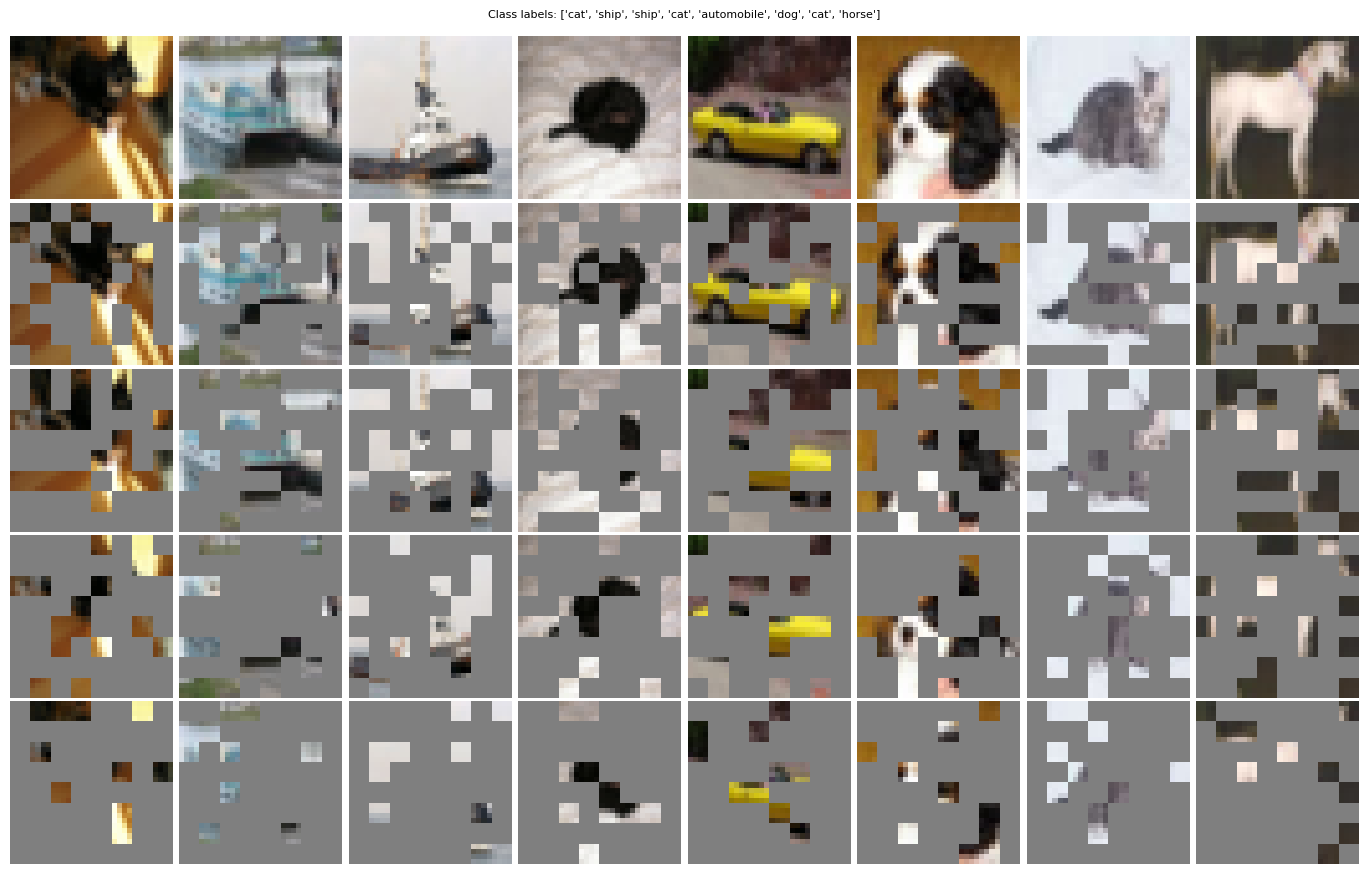

Patch size = 4 px  →  grid = 8×8 patches


In [5]:
# ── 1a: vary mask ratio at fixed patch size ───────────────────
blank_aug = PatchwiseBlankFromMask(BlankConfig(patch_size=PATCH_SIZE, value=BLANK_VALUE))

rows   = [images]
titles = ['Original']
for r in MASK_RATIOS:
    mask = make_mask(B, H, W, PATCH_SIZE, r)
    rows.append(blank_aug(images, mask).detach())
    titles.append(f'Blank  {int(r*100)}% masked\n(patch={PATCH_SIZE}px)')

show_grid(rows, titles)
print(f'Patch size = {PATCH_SIZE} px  →  grid = {H//PATCH_SIZE}×{W//PATCH_SIZE} patches')

#### 1b — Effect of patch size at fixed mask ratio

The patch size changes both **how large the grey blocks are** and **how many tokens the ViT sees**.  
A smaller patch gives the model finer spatial resolution but more tokens to process.

Try changing `PATCH_SIZES` in the config cell — valid values for 32×32: `1, 2, 4, 8, 16, 32`.

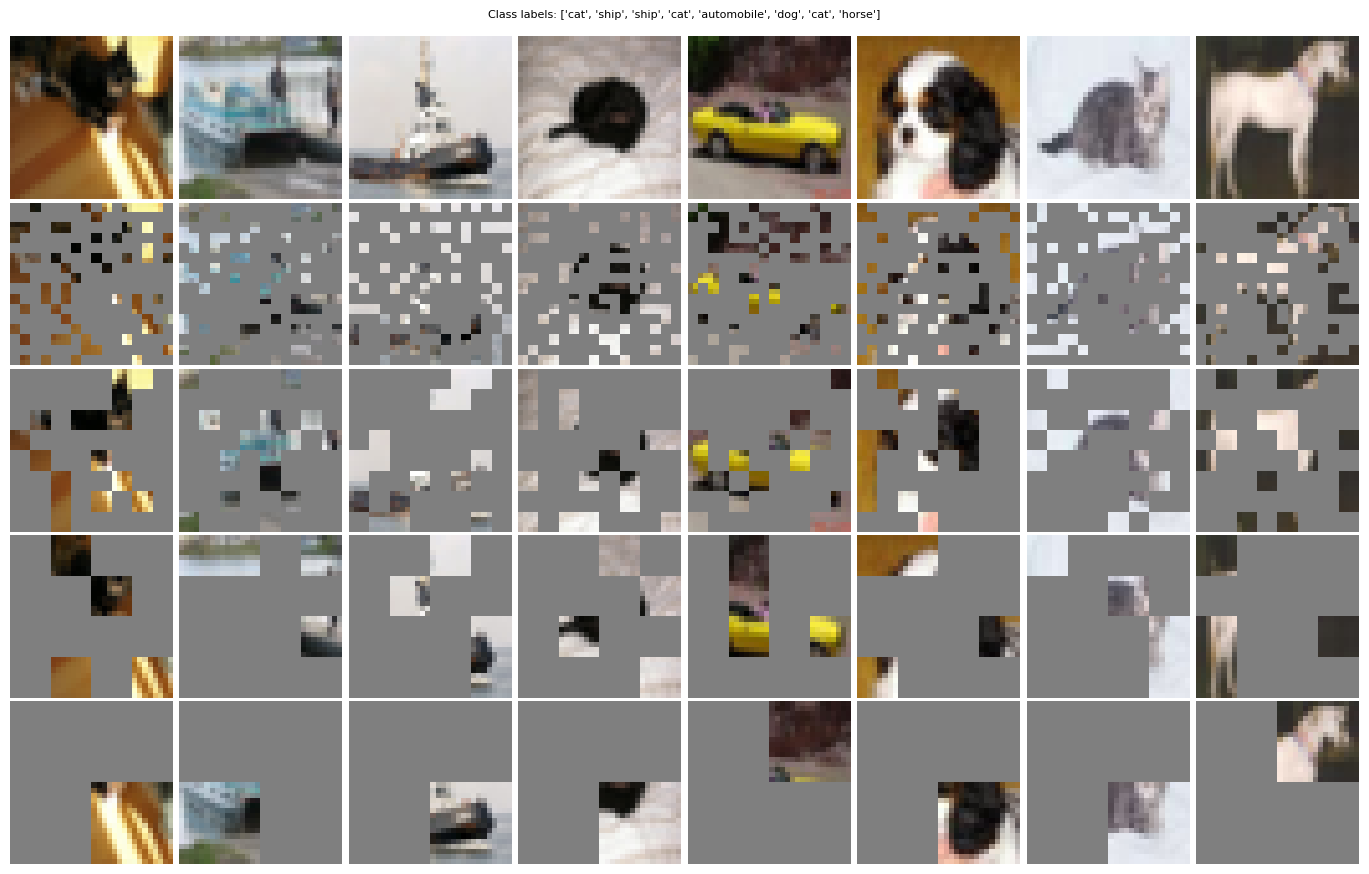


Fixed mask ratio = 0.75
  patch= 2px  →  256 tokens total  (192 masked, 64 visible)
  patch= 4px  →   64 tokens total  (48 masked, 16 visible)
  patch= 8px  →   16 tokens total  (12 masked, 4 visible)
  patch=16px  →    4 tokens total  (3 masked, 1 visible)


In [6]:
# ── 1b: vary patch size at fixed mask ratio ───────────────────
rows   = [images]
titles = ['Original']

for ps in PATCH_SIZES:
    aug  = PatchwiseBlankFromMask(BlankConfig(patch_size=ps, value=BLANK_VALUE))
    mask = make_mask(B, H, W, ps, FIXED_RATIO_P1)
    rows.append(aug(images, mask).detach())
    n_patches = (H // ps) ** 2
    titles.append(f'patch={ps}px\n{n_patches} tokens  {int(FIXED_RATIO_P1*100)}% masked')

show_grid(rows, titles)

print(f'\nFixed mask ratio = {FIXED_RATIO_P1}')
for ps in PATCH_SIZES:
    n = (H // ps) ** 2
    print(f'  patch={ps:2d}px  →  {n:3d} tokens total  '
          f'({int(n * FIXED_RATIO_P1)} masked, {int(n * (1-FIXED_RATIO_P1))} visible)')

---
## Part 2 — Gaussian Blur in the Fourier Domain

Instead of replacing patches with a constant, we **low-pass filter** each masked patch in the Fourier domain.  
The filter is a Gaussian centred at zero frequency:

$$G(f) = \exp\!\left(-\frac{f^2}{2\,\sigma_{\text{ci}}^2}\right)$$

where $f$ is spatial frequency in **cycles / image** and $\sigma_{\text{ci}}$ is the bandwidth parameter you control.

### What does σ control?

| $\sigma_{\text{ci}}$ | Frequencies passed | Pixel-space kernel width $\sigma_{\text{px}} = \frac{N}{2\pi\sigma_{\text{ci}}}$ | Effect |
|---|---|---|---|
| 1 | Only the lowest few | ≈ 5.1 px (on 32×32) | Heavy blur — coarse shape only |
| 2 | Low + some mid | ≈ 2.5 px | Moderate blur |
| 4 | Up to ~¼ Nyquist | ≈ 1.3 px | Mild blur — texture partially visible |
| 8 | Up to ~½ Nyquist | ≈ 0.6 px | Barely perceptible |

> **Key rule:** larger $\sigma_{\text{ci}}$ = *less* blur = more high-frequency detail preserved.  
> This is the **opposite** of the pixel-space convention where larger σ means more blur.

**Try:** Edit `SIGMA_LIST` in the config cell, add very small values (e.g. 0.5) or large ones (e.g. 12), re-run.

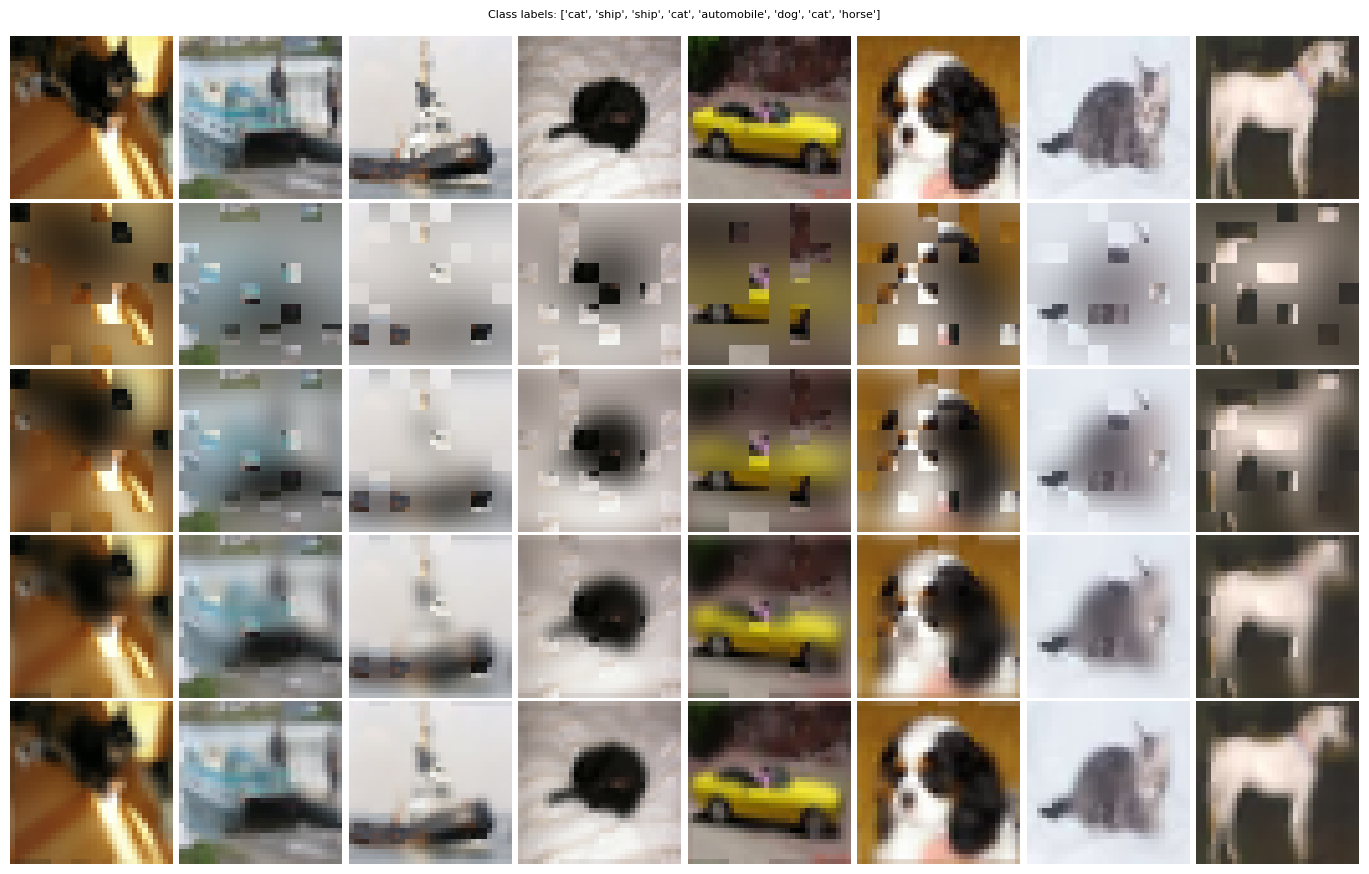


Pixel-space kernel widths (for 32×32 images):
  σ_ci =  1.0  →  σ_px = 5.09 px
  σ_ci =  2.0  →  σ_px = 2.55 px
  σ_ci =  4.0  →  σ_px = 1.27 px
  σ_ci =  8.0  →  σ_px = 0.64 px


In [7]:
mask = make_mask(B, H, W, PATCH_SIZE, FIXED_MASK_RATIO)

rows   = [images]
titles = ['Original']

for sigma in SIGMA_LIST:
    sigma_px = H / (2 * np.pi * sigma)
    aug = PatchwisePyrBlurFromMask(PyrBlurConfig(
        patch_size=PATCH_SIZE,
        blur_type='gaussian',
        gaussian_sigma_ci=sigma,
    ))
    corrupted = aug(images, mask).detach()
    rows.append(corrupted)
    titles.append(f'Gauss  \u03c3_ci={sigma:.1f}  (\u03c3_px\u2248{sigma_px:.1f}px)')

show_grid(rows, titles)

# Print the pixel-space widths for reference
print('\nPixel-space kernel widths (for 32×32 images):')
for sigma in SIGMA_LIST:
    print(f'  \u03c3_ci = {sigma:4.1f}  \u2192  \u03c3_px = {H/(2*np.pi*sigma):.2f} px')

---
## Exercises

Work through these by changing values in the **config cell** and re-running.

1. **Blank masking threshold:**  
   At which mask ratio does it become hard *for you* to recognise the object?  
   Does the answer depend on image complexity (e.g. 'ship' vs 'horse')?

2. **Gaussian sigma extremes:**  
   Set `SIGMA_LIST = [0.3, 0.5, 1.0, 16.0]`.  
   - What does σ = 0.3 look like? (Hint: it is almost a solid-colour patch.)  
   - What does σ = 16 look like compared to the original?

3. **Interaction of mask ratio and sigma:**  
   Fix σ = 2.0 and vary the mask ratio from 0.3 to 0.9.  
   How does the attenuation ratio change with mask ratio for the Gaussian?

4. **Reflection:**  
   Which corruption is a harder reconstruction problem — blank or Gaussian?
